# Well Test Simulator — Pressure Transient Analysis (PTA)

**Workflow**

```
Reservoir inputs (k, h, phi, mu, ct, rw, q, B, Pi, C, S, tp)
        |
Pressure transient simulation  (Laplace-space solution + Stehfest inversion,
                                 wellbore storage + skin, infinite reservoir)
        |
Synthetic buildup data  Pws(dt)
        |
Log-log diagnostic plot: dP and Bourdet derivative vs. equivalent time
        |
Automatic flow-regime identification (wellbore storage / transition / IARF)
        |
Horner analysis on the identified radial-flow window
        |
Estimate k, Pi (P*), skin S
        |
Compare estimated vs. true input values
```

This notebook builds a synthetic well test **from physics**, analyzes it exactly the
way a reservoir engineer would (log-log diagnostic + Horner plot), and then checks
how accurately the interpretation recovers the parameters that were used to generate
the data in the first place. That accuracy check is the core validation for any
well-test-analysis workflow, real or synthetic.


## 1. The physics being simulated

The wellbore pressure response of a well producing at a constant rate, with
wellbore storage ($C$) and skin ($S$), in an infinite-acting homogeneous reservoir,
has a closed-form solution **in Laplace space** (Agarwal, Al-Hussainy & Ramey, 1970):

$$\bar p_D(s) = \frac{K_0(\sqrt{s})}{s^{3/2}\,K_1(\sqrt{s})}$$

$$\bar p_{wD}(s) = \frac{s\,\bar p_D(s) + S}{s\Big[1 + C_D\,s\,\big(s\,\bar p_D(s)+S\big)\Big]}$$

We invert this numerically to real time using the **Stehfest algorithm**, then build
the **buildup** response by superposition of two constant-rate drawdown solutions
(rate $+q$ from $t=0$, rate $-q$ starting at $t=t_p$), which is valid because the
underlying system (diffusivity equation + wellbore-storage ODE) is linear:

$$P_i - P_{ws}(\Delta t) = \frac{141.2\,q\,\mu\,B}{k\,h}\Big[p_{wD}(t_{pD}+\Delta t_D) - p_{wD}(\Delta t_D)\Big]$$

This reproduces the classic diagnostic signature: a **unit-slope** wellbore-storage
line at early time, a **transition** (with a hump if $S>0$, a trough if $S<0$), and a
**flat derivative** once the well "sees" the full reservoir (infinite-acting radial
flow, IARF).


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from welltest_sim import (
    ReservoirParams, simulate_buildup,
    agarwal_equivalent_time, bourdet_derivative,
    classify_points, find_iarf_window,
    horner_regression, estimate_k, estimate_pstar, estimate_skin,
)
from welltest_sim.plotting import plot_loglog, plot_horner

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. Define reservoir & test inputs

Edit these freely — they're the "true" values the interpretation should recover.
All units are field (oilfield) units.


In [2]:
params = ReservoirParams(
    k=50.0,        # permeability, md
    h=40.0,        # net pay thickness, ft
    phi=0.20,      # porosity, fraction
    mu=1.0,        # viscosity, cp
    ct=1.5e-5,     # total compressibility, 1/psi
    rw=0.30,       # wellbore radius, ft
    q=500.0,       # rate before shut-in, STB/D
    B=1.2,         # formation volume factor, rb/STB
    Pi=4500.0,     # initial reservoir pressure, psi
    C=0.01,        # wellbore storage coefficient, bbl/psi
    S=5.0,         # skin factor
    tp=100.0,      # producing time before shut-in, hr
)
print(params.summary())

k=50.0 md, h=40.0 ft, phi=0.2, mu=1.0 cp, ct=1.50e-05 1/psi, rw=0.3 ft, q=500.0 STB/D, B=1.2 rb/STB, Pi=4500.0 psi, C=0.01 bbl/psi, S=5.0, tp=100.0 hr


## 3. Simulate the synthetic buildup test

In [3]:
# Log-spaced shut-in time schedule (as a real gauge would sample: dense early, sparser late)
dt_max = min(params.tp * 3.0, 3000.0)
dt = np.logspace(np.log10(0.001), np.log10(dt_max), 65)

result = simulate_buildup(params, dt, N=12, noise_std=0.0)   # set noise_std>0 for a noisy gauge
Pws = result['Pws']
Pwf_tp = result['Pwf_tp']
dP = Pws - Pwf_tp   # buildup delta-P referenced to the flowing pressure at shut-in

df = pd.DataFrame({'dt_hr': dt, 'Pws_psi': Pws, 'dP_psi': dP})
df.head(10)

,dt_hr,Pws_psi,dP_psi
0,0.001000,3947.446608,2.488934
1,0.001218,3947.986039,3.028364
2,0.001483,3948.641722,3.684047
3,0.001806,3949.438404,4.480730
4,0.002199,3950.405963,5.448288
5,0.002679,3951.580395,6.622721
6,0.003262,3953.004982,8.047308
7,0.003972,3954.731622,9.773947
8,0.004838,3956.822337,11.864663
9,0.005891,3959.350956,14.393282


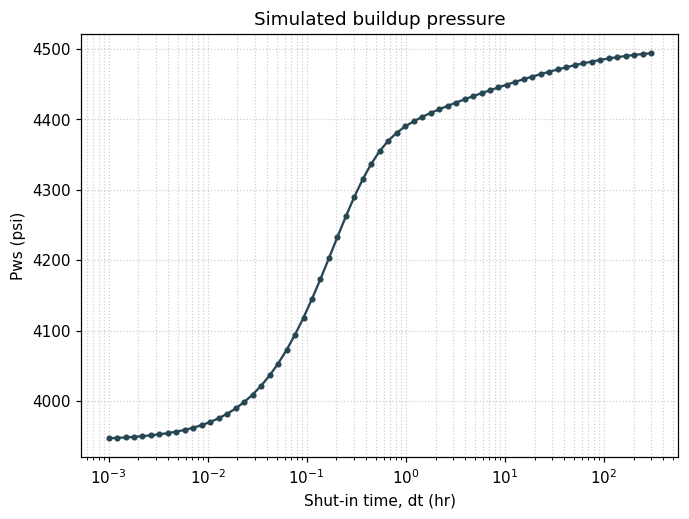

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(dt, Pws, 'o-', ms=3, color='#264653')
ax.set_xlabel('Shut-in time, dt (hr)')
ax.set_ylabel('Pws (psi)')
ax.set_title('Simulated buildup pressure')
ax.grid(True, which='both', ls=':', alpha=0.6)
plt.show()

## 4. Log-log diagnostic plot: $\Delta P$ and the Bourdet derivative

The derivative is computed against **Agarwal equivalent time**
$\Delta t_e = t_p \Delta t / (t_p + \Delta t)$, which maps the buildup response onto
an equivalent drawdown response so standard drawdown type-curve logic applies.

Use `L=0` for a sharp derivative on clean data, or `L=0.1-0.3` (log10 cycles) for
noisy data — this is Bourdet's smoothing algorithm, the same technique used in
commercial well test software.


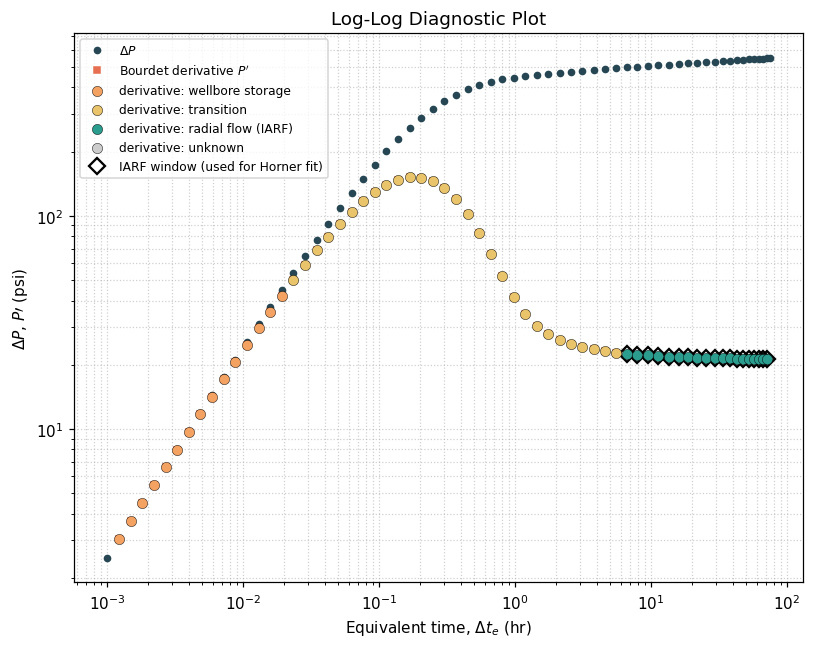

Regime point counts:
  radial flow (IARF)    : 19
  transition            : 29
  unknown               : 2
  wellbore storage      : 15


In [5]:
dte = agarwal_equivalent_time(params.tp, dt)
deriv = bourdet_derivative(dte, dP, L=0.0)

labels = classify_points(dte, deriv)
iarf_mask = find_iarf_window(labels, min_points=5)

fig = plot_loglog(dte, dP, deriv, labels, iarf_mask)
plt.show()

print('Regime point counts:')
lab, cnt = np.unique(labels, return_counts=True)
for l, c in zip(lab, cnt):
    print(f'  {l:22s}: {c}')

## 5. Horner analysis

On the points identified as infinite-acting radial flow (IARF), fit:

$$P_{ws} = P^* - m\,\log_{10}\!\left[\frac{t_p+\Delta t}{\Delta t}\right]$$

* Slope $m$ (psi/log-cycle) $\rightarrow$ permeability: $k = \dfrac{162.6\,q\,\mu\,B}{m\,h}$
* Intercept at Horner ratio $=1$ $\rightarrow$ $P^*$, an estimate of $P_i$
* Standard Horner skin equation using $P_{1hr}$ read off the fitted line


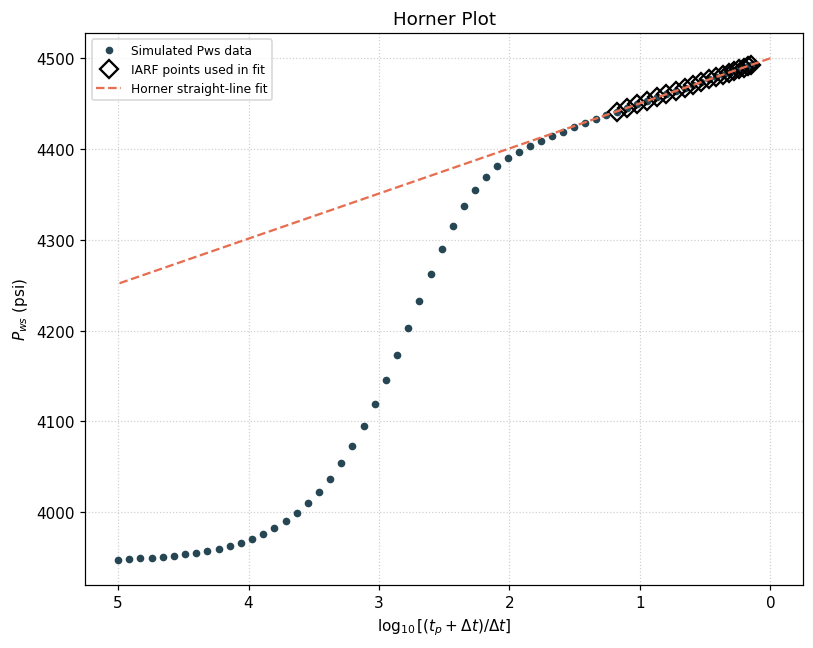

Horner slope m = 49.738 psi/cycle


In [6]:
slope, intercept = horner_regression(params.tp, dt, Pws, iarf_mask)
k_est, m = estimate_k(slope, params.q, params.mu, params.B, params.h)
pstar_est = estimate_pstar(intercept)
S_est = estimate_skin(m, slope, intercept, params.tp, Pwf_tp,
                       k_est, params.phi, params.mu, params.ct, params.rw)

fig = plot_horner(params.tp, dt, Pws, iarf_mask, slope, intercept)
plt.show()

print(f'Horner slope m = {m:.3f} psi/cycle')

## 6. Accuracy check: estimated vs. true (input) parameters

In [7]:
rows = [
    ('Permeability, k (md)', params.k, k_est),
    ('Initial pressure, Pi / P* (psi)', params.Pi, pstar_est),
    ('Skin factor, S', params.S, S_est),
]
report = pd.DataFrame(rows, columns=['Parameter', 'True (input)', 'Estimated'])
report['Error (%)'] = 100*(report['Estimated']-report['True (input)'])/report['True (input)']
report

,Parameter,True (input),Estimated,Error (%)
0,"Permeability, k (md)",50.0,49.036485,-1.927030
1,"Initial pressure, Pi / P* (psi)",4500.0,4500.265077,0.005891
2,"Skin factor, S",5.0,4.754858,-4.902833


## 7. Try it with noisy data (a more realistic gauge)

Real downhole gauges have noise. Add Gaussian noise to the simulated pressure and
re-run the same pipeline — note the switch to the smoothed derivative (`L>0`),
which is the standard technique for keeping the diagnostic plot usable on noisy data.


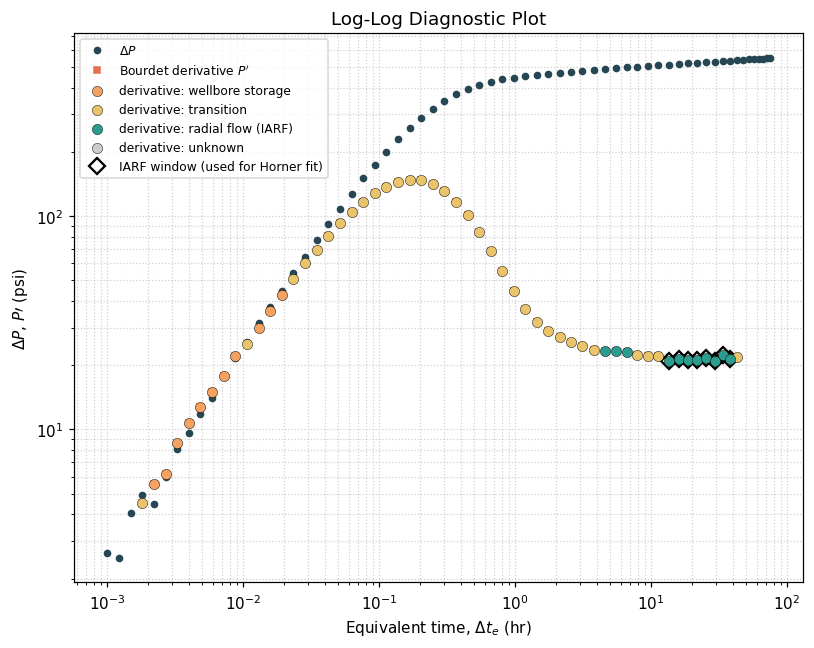

,Parameter,True (input),Estimated,Error (%)
0,"Permeability, k (md)",50.0,50.019555,0.039109
1,"Initial pressure, Pi / P* (psi)",4500.0,4499.610480,-0.008656
2,"Skin factor, S",5.0,4.987105,-0.257891


In [8]:
result_noisy = simulate_buildup(params, dt, N=12, noise_std=0.5, seed=42)
Pws_n = result_noisy['Pws']
Pwf_tp_n = result_noisy['Pwf_tp']
dP_n = Pws_n - Pwf_tp_n

deriv_n = bourdet_derivative(dte, dP_n, L=0.2)   # L-algorithm smoothing
labels_n = classify_points(dte, deriv_n)
iarf_mask_n = find_iarf_window(labels_n, min_points=5)

fig = plot_loglog(dte, dP_n, deriv_n, labels_n, iarf_mask_n)
plt.show()

slope_n, intercept_n = horner_regression(params.tp, dt, Pws_n, iarf_mask_n)
k_est_n, m_n = estimate_k(slope_n, params.q, params.mu, params.B, params.h)
pstar_est_n = estimate_pstar(intercept_n)
S_est_n = estimate_skin(m_n, slope_n, intercept_n, params.tp, Pwf_tp_n,
                         k_est_n, params.phi, params.mu, params.ct, params.rw)

rows_n = [
    ('Permeability, k (md)', params.k, k_est_n),
    ('Initial pressure, Pi / P* (psi)', params.Pi, pstar_est_n),
    ('Skin factor, S', params.S, S_est_n),
]
report_n = pd.DataFrame(rows_n, columns=['Parameter', 'True (input)', 'Estimated'])
report_n['Error (%)'] = 100*(report_n['Estimated']-report_n['True (input)'])/report_n['True (input)']
report_n